In [1]:
import matplotlib.pyplot as plt
import numpy as np
from p3.aoSystem.fourierModel import fourierModel
from p3.aoSystem.frequencyDomain import frequencyDomain
from p3.aoSystem.FourierUtils import radial_profile

Cupy import failed. P3 will fall back to CPU use.
Cupy import failed. MASTSEL will fall back to CPU use.


In [2]:
fname = 'EKARUS'
fao = fourierModel(path_ini=f'/raid1/mmenessini/git/P3/p3/aoSystem/parFiles/{fname}.ini',display=False, verbose=True,getErrorBreakDown=True)

Cupy import failed. MASTSEL will fall back to CPU use.
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2

_____ ERROR BREAKDOWN  ON-AXIS_____
------------------------------------------
.Image Strehl at 0.75micron:	70.84%
.Maréchal Strehl at 0.75micron:	69.83%
.Residual wavefront error:	71.54nm
.NCPA residual:			0.00nm
.Fitting error:			41.88nm
.Differential refraction:	0.00nm
.Chromatic error:		0.00nm
.Aliasing error:		5.87nm
.Noise error:			44.21nm
.Spatio-temporal error:		37.08nm
.Wind-shake error:		0.00nm
.Additionnal jitter:		0.00mas / 0.00nm
.Extra error:			0.00nm
-------------------------------------------
.Sole servoLag error:		37.08nm
.Sole reconstruction error:	0.00nm
-------------------------------------------
.Sole anisoplanatism error:	0.00nm
-------------------------------------------

EXECUTION TIME BREAKDOWN

Total calculation time:                          554.9 ms
AO sys

Text(0.5, 1.0, 'Aliasing')

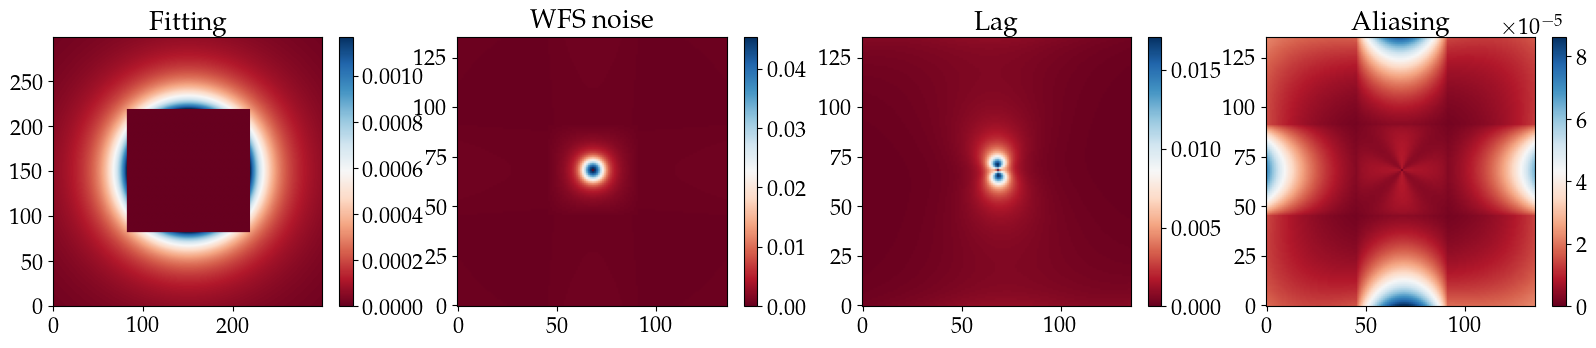

In [3]:
aliasPSD = fao.aliasingPSD()
servoLagPSD = fao.servoLagPSD()
fittingPSD = fao.fittingPSD()
noisePSD = fao.noisePSD()

plt.figure(figsize=(20,3.5))
plt.subplot(1,4,1)
plt.imshow(fittingPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Fitting')
plt.subplot(1,4,2)
plt.imshow(noisePSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('WFS noise')
plt.subplot(1,4,3)
plt.imshow(servoLagPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Lag')
plt.subplot(1,4,4)
plt.imshow(aliasPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Aliasing')

(0.0, 40.0)

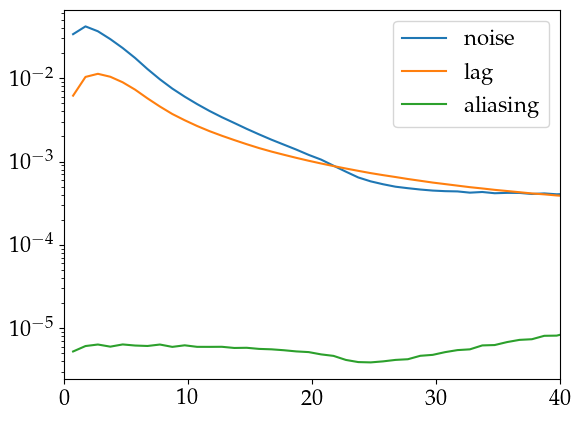

In [4]:
rad_bin, noise_profile = radial_profile(noisePSD)
rad_bin, lag_profile = radial_profile(servoLagPSD)
rad_bin, alias_profile = radial_profile(aliasPSD)
rad_bin_fit, fit_profile = radial_profile(fittingPSD)

plt.figure()
plt.semilogy(rad_bin, noise_profile,label='noise')
plt.semilogy(rad_bin, lag_profile,label='lag')
plt.semilogy(rad_bin, alias_profile,label='aliasing')
# plt.semilogy(rad_bin_fit[::2], fit_profile[::2],label='fitting')
plt.legend()
# plt.grid()
plt.xlim([0,40])

In [5]:
def get_flux(fao, mag:float, B0=10**10):
    thrp = fao.ao.wfs.detector[0].transmittance[0]
    area = np.pi/4*fao.ao.tel.D**2*(1-fao.ao.tel.obsRatio**2)
    thrp *= 1.0-np.exp(-(0.35+0.72*fao.ao.wfs.optics[0].modulation))
    return area * thrp * B0 * 10**(-mag/2.5)

def update_ao_pars(fao, delay=None, gain=None, mag=None, fs=None, Nsubap=None, nModes=None, rMod=None, binning=None):
    
    if gain is not None:
        fao.ao.rtc.holoop['gain'] = gain
    if delay is not None:
        fao.ao.rtc.holoop['delay'] = delay
    if fs is not None:
        fao.ao.rtc.holoop['rate'] = fs
    if rMod is not None:
        fao.ao.wfs.optics[0].modulation = rMod
    if Nsubap is not None:
        fao.ao.wfs.optics[0].nL = Nsubap
        fao.ao.wfs.optics[0].dsub = fao.ao.tel.D/Nsubap

    if binning is not None:
        fao.ao.wfs.detector[0].binning = binning
                
    if mag is not None:
        total_flux = get_flux(fao, mag)
    else:
        total_flux = fao.ao.wfs.detector[0].nph * fao.ao.rtc.holoop['rate'] * fao.ao.wfs.optics[0].nL**2 * np.pi/4
    fs = fao.ao.rtc.holoop['rate']
    nSubap = fao.ao.wfs.optics[0].nL**2 * np.pi/4
    flux_per_sub = total_flux / fs / nSubap
    fao.ao.wfs.detector[0].nph = flux_per_sub

    if nModes is not None:
        nActs = np.sqrt(nModes*4/np.pi)
        fao.ao.dms.nActu1D = nActs
        fao.ao.dms.pitch = fao.ao.tel.D/nActs
        fao.freq = frequencyDomain(
                    fao.ao,
                    nyquistSampling=fao.nyquistSampling,
                    computeFocalAnisoCov=fao.computeFocalAnisoCov,
                    dtype=fao.dtype
                )
    
    fao.ao.wfs.processing.noiseVar = [None]
    

def get_error_breakdown(fao):
    fao.ao.error = False
    fao.getErrorBreakdown = True
    fao.initComputations()

    # try:
    idCenter = fao.ao.src.zenith.argmin()
    error = {'fitting': fao.wfeFit, 'lag': fao.wfeS, 'noise': fao.wfeN[idCenter], 'aliasing': fao.wfeAl, 'total': fao.wfeTot[idCenter]}
    # except IndexError:
    #     error = {'fitting': fao.wfeFit, 'noise': fao.wfeN, 'aliasing': fao.wfeAl, 'lag': fao.wfeS, 'total': fao.wfeTot}

    return error

fao.verbose = False

In [6]:
eb0 = get_error_breakdown(fao)
# print(fao.ao.wfs.detector[0].nph)
update_ao_pars(fao, rMod=0) #mag = 7.5, fs = 1500, delay = 3.5, gain = 0.5, 
eb1 = get_error_breakdown(fao)

In [7]:
print(eb0,'\n',eb1)

{'fitting': 41.880634597267125, 'lag': 37.07602745530296, 'noise': 44.208706698585964, 'aliasing': 5.867252566170262, 'total': 71.5363807217909} 
 {'fitting': 41.880634597267125, 'lag': 37.07602745530301, 'noise': 26.824635414852047, 'aliasing': 4.237608721498608, 'total': 62.178274010722156}


In [8]:

fao = fourierModel(path_ini=f'/raid1/mmenessini/git/P3/p3/aoSystem/parFiles/{fname}.ini',display=False, verbose=True,getErrorBreakDown=True,compute_og=True)

Cupy import failed. MASTSEL will fall back to CPU use.
0


ValueError: non-broadcastable output operand with shape (136,136,1) doesn't match the broadcast shape (136,136,136)